In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\hanaa\Downloads\Real estate dataset (1).csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [2]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
df.describe()

(414, 8)
Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [3]:
df = df.rename(columns={
"X1 transaction date": "date",
"X2 house age": "age",
"X3 distance to the nearest MRT station": "mrt_distance",
"X4 number of convenience stores": "stores",
"X5 latitude": "lat",
"X6 longitude": "lon",
"Y house price of unit area": "price_unit"
})
df.head()

,No,date,age,mrt_distance,stores,lat,lon,price_unit
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


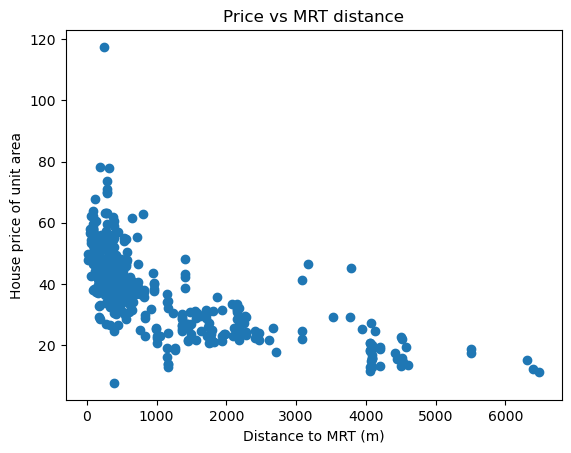

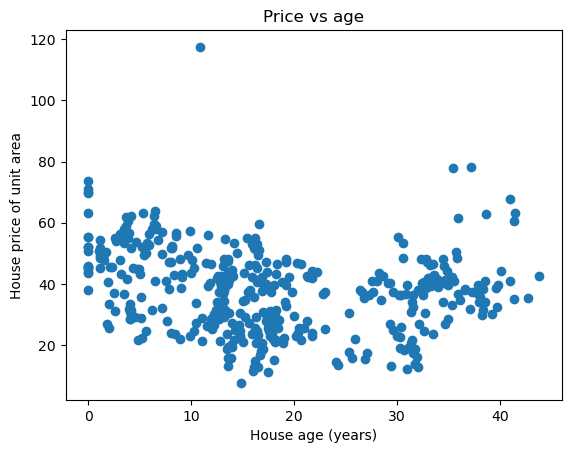

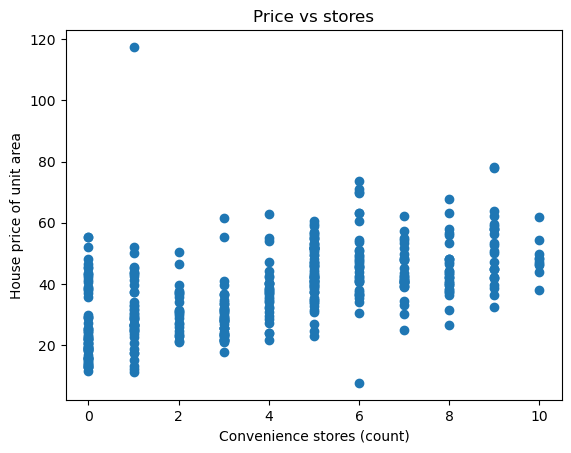

In [4]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(df["mrt_distance"], df["price_unit"])
plt.xlabel("Distance to MRT (m)")
plt.ylabel("House price of unit area")
plt.title("Price vs MRT distance")
plt.show()
plt.figure()
plt.scatter(df["age"], df["price_unit"])
plt.xlabel("House age (years)")
plt.ylabel("House price of unit area")
plt.title("Price vs age")
plt.show()
plt.figure()
plt.scatter(df["stores"], df["price_unit"])
plt.xlabel("Convenience stores (count)")
plt.ylabel("House price of unit area")
plt.title("Price vs stores")
plt.show()

In [5]:
df[["date","age","mrt_distance","stores","lat","lon","price_unit"]].corr()

,date,age,mrt_distance,stores,lat,lon,price_unit
date,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
age,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
mrt_distance,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
stores,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
lat,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
lon,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
price_unit,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df[["mrt_distance"]]
y = df["price_unit"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
print("Intercept:", model_1.intercept_)
print("Coefficient:", model_1.coef_[0])

Intercept: 46.24269004533652
Coefficient: -0.007409512934932927


In [7]:
import sys
print(sys.executable)

C:\Users\hanaa\anaconda3\python.exe


MAE: 6.920972703573579
RMSE: 8.79454329599807
R2: 0.5389597665019772


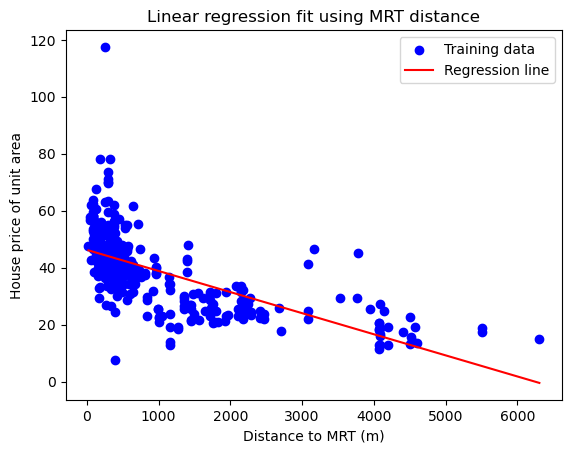

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Predictions
pred = model_1.predict(X_test)

# 2️⃣ Metrics
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # works in all sklearn versions
r2 = r2_score(y_test, pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# 3️⃣ Plot
plt.figure()
plt.scatter(X_train, y_train, color='blue', label='Training data')

x_line = np.linspace(X_train.min().values[0], X_train.max().values[0], 200).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=X_train.columns)  # ✅ fix for sklearn warning
plt.plot(x_line, model_1.predict(x_line_df), color='red', label='Regression line')

plt.xlabel("Distance to MRT (m)")
plt.ylabel("House price of unit area")
plt.title("Linear regression fit using MRT distance")
plt.legend()
plt.show()



In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Select features and target
features = ["date", "age", "mrt_distance", "stores", "lat", "lon"]
X = df[features]
y = df["price_unit"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train multiple linear regression
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Make predictions
pred = model_multi.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, pred))  # works on all sklearn versions
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

# Display coefficients
coef_table = pd.Series(model_multi.coef_, index=features).sort_values()
print("Coefficients:")
print(coef_table)

# Intercept
print("Intercept:", model_multi.intercept_)

RMSE: 7.314753524521961
R2: 0.6810580555095684
Coefficients:
lon             -29.492591
age              -0.270791
mrt_distance     -0.004759
stores            1.091425
date              5.440742
lat             229.043054
dtype: float64
Intercept: -13044.231917160501


In [11]:
import numpy as np
X = df[features].values
y = df["price_unit"].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
theta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
theta[:5]

array([[-1.30442323e+04],
       [ 5.44074200e+00],
       [-2.70791490e-01],
       [-4.75863891e-03],
       [ 1.09142527e+00]])

In [22]:
import numpy as np

def batch_gradient_descent(X, y, learning_rate=0.01, epochs=2000):
    # ensure numpy arrays and proper shape
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)
    
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]  # add bias term
    theta = np.zeros((n + 1, 1))
    history = []

    for epoch in range(epochs):
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        theta = theta - learning_rate * gradients

        if epoch % 100 == 0:
            rmse = np.sqrt(((X_b @ theta - y) ** 2).mean())
            history.append((epoch, rmse))

    return theta, history

In [24]:
# very small learning rate to avoid NaNs
theta_ns, hist_ns = batch_gradient_descent(X_train, y_train,
                                           learning_rate=1e-8, epochs=5000)

# last 5 RMSE values
print(hist_ns[-5:])

[(4500, np.float64(10.330462357217538)), (4600, np.float64(10.33028173288304)), (4700, np.float64(10.33010119334774)), (4800, np.float64(10.329920738571213)), (4900, np.float64(10.32974036851305))]


C:\Users\hanaa\AppData\Local\Temp\ipykernel_28224\54699199.py:14: RuntimeWarning: overflow encountered in matmul
  gradients = (2/m) * X_b.T @ (X_b @ theta - y)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_28224\54699199.py:14: RuntimeWarning: invalid value encountered in matmul
  gradients = (2/m) * X_b.T @ (X_b @ theta - y)


Final coefficients:
 [[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]


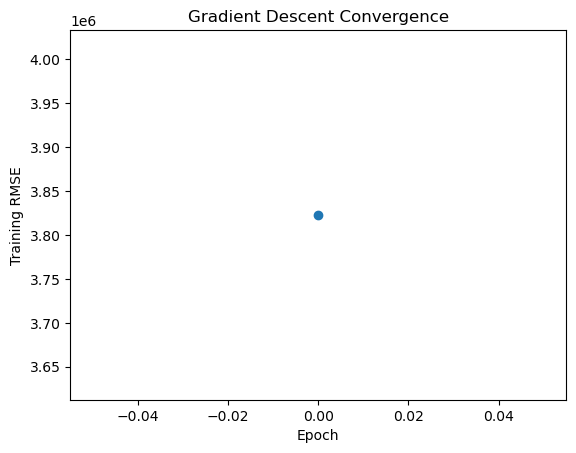

In [23]:
# Run gradient descent
theta, history = batch_gradient_descent(X_train, y_train, learning_rate=0.01, epochs=2000)

print("Final coefficients:\n", theta)

# Plot RMSE convergence
import matplotlib.pyplot as plt

plt.figure()
plt.plot([h[0] for h in history], [h[1] for h in history], marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Gradient Descent Convergence")
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
theta_s, hist_s = batch_gradient_descent(X_train_scaled, y_train,
                                         learning_rate=0.01, epochs=5000)

# last 5 RMSE values
print(hist_s[-5:])

[(4500, np.float64(9.116659612434624)), (4600, np.float64(9.116659612434612)), (4700, np.float64(9.116659612434601)), (4800, np.float64(9.116659612434598)), (4900, np.float64(9.116659612434596))]


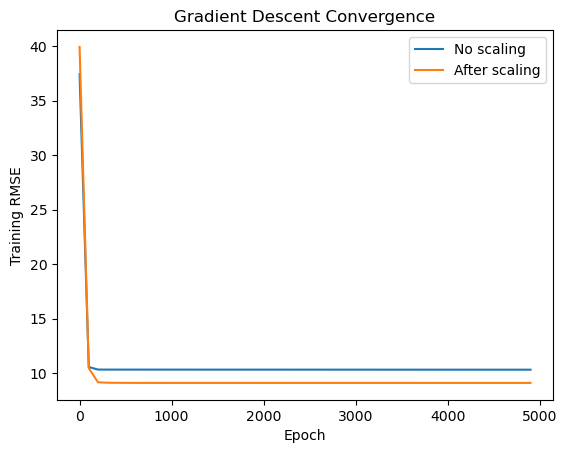

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot([h[0] for h in hist_ns], [h[1] for h in hist_ns], label='No scaling')
plt.plot([h[0] for h in hist_s], [h[1] for h in hist_s], label='After scaling')
plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.show()

Degree 1: RMSE=8.79, R²=0.54
Degree 2: RMSE=8.33, R²=0.59
Degree 3: RMSE=7.82, R²=0.64
Degree 4: RMSE=7.73, R²=0.64
Degree 5: RMSE=8.89, R²=0.53


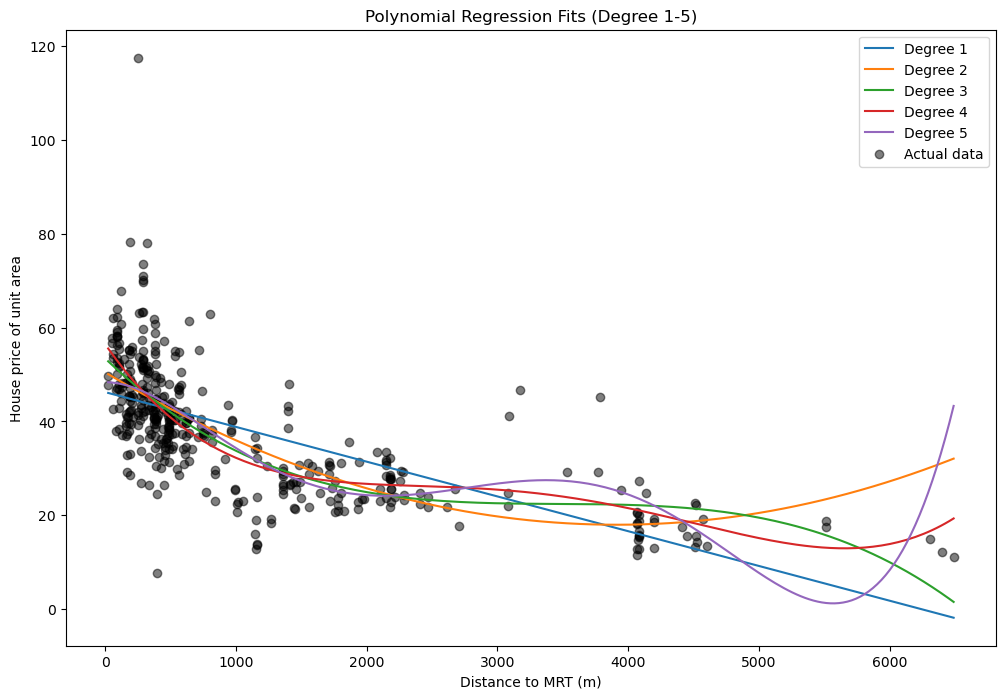

In [29]:
# -----------------------------
# Part G: Polynomial Regression
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\hanaa\Downloads\Real estate dataset (1).csv")
df = df.rename(columns={
    "X1 transaction date": "date",
    "X2 house age": "age",
    "X3 distance to the nearest MRT station": "mrt_distance",
    "X4 number of convenience stores": "stores",
    "X5 latitude": "lat",
    "X6 longitude": "lon",
    "Y house price of unit area": "price_unit"
})

# Feature and target
X = df[["mrt_distance"]].values
y = df["price_unit"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Test multiple polynomial degrees
degrees = [1, 2, 3, 4, 5]
plt.figure(figsize=(12, 8))
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

for d in degrees:
    # Transform features
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    x_line_poly = poly.transform(x_line)
    
    # Train model
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)
    
    # Predict
    y_train_pred = model_poly.predict(X_train_poly)
    y_test_pred = model_poly.predict(X_test_poly)
    y_line = model_poly.predict(x_line_poly)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)
    print(f"Degree {d}: RMSE={rmse:.2f}, R²={r2:.2f}")
    
    # Plot predictions
    plt.plot(x_line, y_line, label=f"Degree {d}")

# Scatter actual data
plt.scatter(X, y, color='black', alpha=0.5, label='Actual data')
plt.xlabel("Distance to MRT (m)")
plt.ylabel("House price of unit area")
plt.title("Polynomial Regression Fits (Degree 1-5)")
plt.legend()
plt.show()

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster_features = ["mrt_distance","stores","lat","lon","age"]
Xc = df[cluster_features].values
Xc = StandardScaler().fit_transform(Xc)

C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

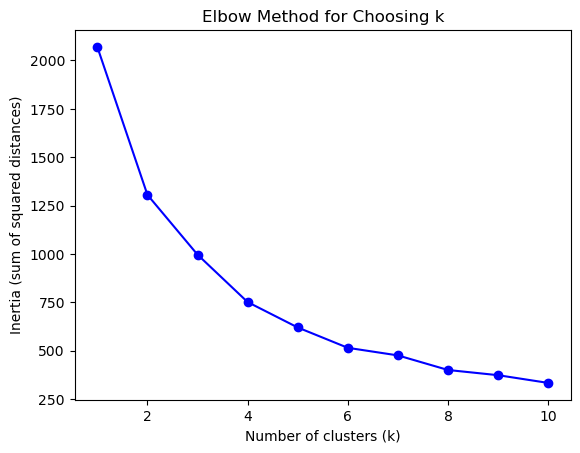

In [31]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)  # test 1 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(Xc)
    inertia.append(kmeans.inertia_)

# Plot elbow
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (sum of squared distances)')
plt.title('Elbow Method for Choosing k')
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("Real estate dataset.csv")
df.head()

df = df.rename(columns={
"X1 transaction date": "date",
"X2 house age": "age",
"X3 distance to the nearest MRT station": "mrt_distance",
"X4 number of convenience stores": "stores",
"Y house price of unit area": "price_unit"
})
df.head()

features = ["date","age","mrt_distance","stores"]
X = df[features]
y = df["price_unit"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

pred = model_multi.predict(X_test)
print("RMSE:", mean_squared_error(y_test, pred, squared=False))
print("R2:", r2_score(y_test, pred))
coef_table = pd.Series(model_multi.coef_, index=features).sort_values()
print(coef_table)
print("Intercept:", model_multi.intercept_)